# Introduction

This project focuses on developing a machine learning–based system for evaluating risk in sports betting. The goal is not to predict outcomes with certainty, but to estimate probabilities of match results and identify potential value in betting decisions based on historical data.
The system processes and analyzes real-world (often imperfect) datasets, applying data cleaning, feature engineering, and predictive modeling techniques. In addition, the project aims to present the results through a simple and intuitive mobile interface, allowing users to better understand risk levels and make more informed decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries loaded successfully!")

✓ All libraries loaded successfully!


# Data Collection

The dataset used in this project was obtained from publicly available historical football data provided by Football-Data.co.uk. This source offers structured match-level data across multiple leagues and seasons, including key information such as match dates, teams, results, and bookmaker odds.

For this project, data from the English Premier League (E0) was selected due to its consistency, data quality, and availability of detailed betting odds. A total of the most recent 10 seasons were included in the analysis to ensure a sufficient volume of data while preserving relevance to modern football and betting market conditions.

Using recent seasons is important because football dynamics, team performance patterns, and bookmaker pricing strategies evolve over time. Older data may reflect outdated trends and less efficient markets, which can negatively impact model performance. By focusing on the last decade, the dataset remains both large enough for training and representative of current real-world scenarios.

The data was accessed in CSV format, which allows for easy integration with data analysis tools such as pandas. This also ensures a consistent structure across seasons, simplifying preprocessing and feature engineering.

This approach ensures that the model is trained on reliable, realistic, and up-to-date information, making the analysis more applicable to real-world betting scenarios.


---




In [ ]:
LEAGUES = [
    ("Premier League",  "england", "E0"),
    ("La Liga",         "spain",   "SP1"),
    ("Bundesliga",      "germany", "D1"),
    ("Serie A",         "italy",   "I1"),
]

SEASONS = [
    ("2015/16", "1516"),
    ("2016/17", "1617"),
    ("2017/18", "1718"),
    ("2018/19", "1819"),
    ("2019/20", "1920"),
    ("2020/21", "2021"),
    ("2021/22", "2122"),
    ("2022/23", "2223"),
    ("2023/24", "2324"),
    ("2024/25", "2425"),
]

BASE_URL = "https://www.football-data.co.uk/mmz4281"

all_dfs = []

for league_name, country, league_code in LEAGUES:
    for season_name, season_code in SEASONS:
        url = f"{BASE_URL}/{season_code}/{league_code}.csv"
        try:
            df = pd.read_csv(url)
            df['League'] = league_name
            df['Season'] = season_name
            all_dfs.append(df)
            print(f"✓ {league_name} {season_name}")
        except:
            print(f"✗ {league_name} {season_name} - not found")

# Merge all datasets
df_raw = pd.concat(all_dfs, ignore_index=True)
print(f"\n📊 Total records: {len(df_raw)}")
print(f"📊 Total columns: {df_raw.shape[1]}")

✓ Premier League 2015/16
✓ Premier League 2016/17
✓ Premier League 2017/18
✓ Premier League 2018/19
✓ Premier League 2019/20
✓ Premier League 2020/21
✓ Premier League 2021/22
✓ Premier League 2022/23
✓ Premier League 2023/24
✓ Premier League 2024/25
✓ La Liga 2015/16
✓ La Liga 2016/17
✓ La Liga 2017/18
✓ La Liga 2018/19
✓ La Liga 2019/20
✓ La Liga 2020/21
✓ La Liga 2021/22
✓ La Liga 2022/23
✓ La Liga 2023/24
✓ La Liga 2024/25
✓ Bundesliga 2015/16
✓ Bundesliga 2016/17
✓ Bundesliga 2017/18
✓ Bundesliga 2018/19
✓ Bundesliga 2019/20
✓ Bundesliga 2020/21
✓ Bundesliga 2021/22
✓ Bundesliga 2022/23
✓ Bundesliga 2023/24
✓ Bundesliga 2024/25
✓ Serie A 2015/16
✓ Serie A 2016/17
✓ Serie A 2017/18
✓ Serie A 2018/19
✓ Serie A 2019/20
✓ Serie A 2020/21
✓ Serie A 2021/22
✓ Serie A 2022/23
✓ Serie A 2023/24
✓ Serie A 2024/25

📊 Total records: 14461
📊 Total columns: 155


# Preprocessing

## Data cleaning

Data cleaning is a crucial step in the machine learning pipeline, as the quality of the data directly affects model performance. In this stage, the dataset is examined for missing values, duplicate records, outliers, and inconsistent data types. Basic preprocessing techniques such as outlier handling and feature scaling are applied to prepare the data for classical machine learning algorithms.

### Select Optimal Columns

In [ ]:
optimal_cols = [
    'Date',
    'HomeTeam',
    'AwayTeam',
    'FTHG', 'FTAG', 'FTR',        # Full time result (TARGET)
    'HTHG', 'HTAG', 'HTR',        # Half time result
    'HS', 'AS',                   # Shots
    'HST', 'AST',                 # Shots on Target
    'HC', 'AC',                   # Corners
    'HF', 'AF',                   # Fouls
    'HY', 'AY',                   # Yellow cards
    'HR', 'AR',                   # Red cards
    'B365H', 'B365D', 'B365A',    # Betting odds
    'League',
    'Season'
]

df = df_raw[[col for col in optimal_cols if col in df_raw.columns]].copy()
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset shape: (14461, 26)

First 5 rows:
         Date     HomeTeam     AwayTeam  FTHG  FTAG FTR  HTHG  HTAG HTR    HS  \
0  08/08/2015  Bournemouth  Aston Villa   0.0   1.0   A   0.0   0.0   D  11.0   
1  08/08/2015      Chelsea      Swansea   2.0   2.0   D   2.0   1.0   H  11.0   
2  08/08/2015      Everton      Watford   2.0   2.0   D   0.0   1.0   A  10.0   
3  08/08/2015    Leicester   Sunderland   4.0   2.0   H   3.0   0.0   H  19.0   
4  08/08/2015   Man United    Tottenham   1.0   0.0   H   1.0   0.0   H   9.0   

   ...    AF   HY   AY   HR   AR  B365H  B365D  B365A          League   Season  
0  ...  13.0  3.0  4.0  0.0  0.0   2.00    3.6   4.00  Premier League  2015/16  
1  ...  16.0  1.0  3.0  1.0  0.0   1.36    5.0  11.00  Premier League  2015/16  
2  ...  13.0  1.0  2.0  0.0  0.0   1.70    3.9   5.50  Premier League  2015/16  
3  ...  17.0  2.0  4.0  0.0  0.0   1.95    3.5   4.33  Premier League  2015/16  
4  ...  12.0  2.0  3.0  0.0  0.0   1.65    4.0   6.00  Premier Lea

**Selected Features and Rationale**

The original dataset contains over 100 columns, including odds from multiple bookmakers and additional betting markets. To reduce noise and ensure consistency, a subset of relevant features was selected based on their interpretability and predictive value.

Below is a description of each selected column and the reasoning behind its inclusion:

**Match Information**

* **Date** — Date of the match.
  Used for time-based analysis, sorting, and feature engineering (e.g., team form).

* **League** — Competition identifier.
  Helps distinguish between different leagues if multiple datasets are combined.

* **Season** — Season of the match.
  Allows tracking long-term trends and prevents mixing data from different time periods.

---

**Teams**

* **HomeTeam** — Home team name.
* **AwayTeam** — Away team name.
  Essential for modeling team-specific behavior and historical performance.

---

**Match Outcome (Targets & Core Results)**

* **FTHG** — Full-time home team goals.
* **FTAG** — Full-time away team goals.
* **FTR** — Full-time result (H = Home win, D = Draw, A = Away win).
  These define the actual match outcome and are used to create the prediction target.

---

**Half-Time Information**

* **HTHG** — Half-time home goals.
* **HTAG** — Half-time away goals.
* **HTR** — Half-time result.
  Provide additional context about match dynamics and potential momentum.

---

**Match Statistics**

* **HS / AS** — Total shots (home/away).
* **HST / AST** — Shots on target (home/away).
* **HC / AC** — Corners (home/away).
* **HY / AY** — Yellow cards (home/away).
* **HR / AR** — Red cards (home/away).

These features describe in-game performance and team behavior, which can help the model capture differences in playing style, dominance, and discipline.

---

**Betting Odds (Bet365)**

* **B365H** — Odds for home win
* **B365D** — Odds for draw
* **B365A** — Odds for away win

These are the bookmaker’s implied probabilities and serve as a strong baseline. They are critical for:

* estimating implied probabilities
* comparing model predictions with market expectations
* identifying potential value bets

---

**Why only these columns?**

* To **reduce dimensionality** and avoid overfitting
* To ensure **data consistency across seasons**
* To focus on **interpretable and high-impact features**
* To avoid redundancy from multiple bookmakers offering similar information

This subset provides a balanced representation of:

* match outcomes
* team behavior
* betting market expectations

which are all essential for building a robust predictive model.


### Check Missing Values



In [ ]:
# Check missing values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Percent', ascending=False)

print("❌ Missing values:")
print(missing_df[missing_df['Missing_Count'] > 0])

# Remove rows with NaN
df = df.dropna()
print(f"\n✓ Dataset after removing NaN: {df.shape}")
print(f"✓ Rows removed: {df_raw.shape[0] - df.shape[0]}")

❌ Missing values:
      Column  Missing_Count  Missing_Percent
23     B365A              4         0.027661
22     B365D              4         0.027661
21     B365H              4         0.027661
6       HTHG              3         0.020745
8        HTR              3         0.020745
7       HTAG              3         0.020745
10        AS              2         0.013830
9         HS              2         0.013830
11       HST              2         0.013830
14        AC              2         0.013830
17        HY              2         0.013830
16        AF              2         0.013830
15        HF              2         0.013830
18        AY              2         0.013830
20        AR              2         0.013830
19        HR              2         0.013830
12       AST              2         0.013830
13        HC              2         0.013830
2   AwayTeam              1         0.006915
3       FTHG              1         0.006915
4       FTAG              1         0

### Check for Duplicates

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"🔍 Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Dataset after removing duplicates: {df.shape}")
else:
    print("✓ No duplicates found")

🔍 Number of duplicate rows: 0
✓ No duplicates found


### Outlier Detection Using IQR Method

In [ ]:
# Identify outliers using IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns

outlier_indices = set()
outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices.update(outliers)

    if len(outliers) > 0:
        outlier_report[col] = len(outliers)

print(f"📍 Total unique rows with outliers: {len(outlier_indices)}")
print(f"\nTop 10 columns with outliers:")
for col, count in sorted(outlier_report.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {col}: {count}")

📍 Total unique rows with outliers: 6355

Top 10 columns with outliers:
  B365D: 1436
  AR: 1385
  B365H: 1246
  B365A: 1210
  FTHG: 1188
  HR: 1143
  HTHG: 510
  HST: 489
  AC: 360
  AST: 348


### Outlier Clipping (Capping)

In [ ]:
# Apply clipping for extreme values
df['B365H'] = df['B365H'].clip(upper=15)
df['B365D'] = df['B365D'].clip(upper=10)
df['B365A'] = df['B365A'].clip(upper=20)

df['HC'] = df['HC'].clip(upper=20)
df['AC'] = df['AC'].clip(upper=15)

df['HS'] = df['HS'].clip(upper=35)
df['AS'] = df['AS'].clip(upper=30)
df['HST'] = df['HST'].clip(upper=15)
df['AST'] = df['AST'].clip(upper=15)

print("✓ Outlier clipping applied to betting odds and game statistics")
print(f"\nUpdated statistics:")
print(df[['B365H', 'B365D', 'B365A', 'HS', 'AS', 'HST', 'AST']].describe())

✓ Outlier clipping applied to betting odds and game statistics

Updated statistics:
              B365H         B365D         B365A            HS            AS  \
count  14455.000000  14455.000000  14455.000000  14455.000000  14455.000000   
mean       2.814149      4.110502      4.547588     13.576133     11.129436   
std        1.975441      1.265018      3.633297      5.335979      4.739184   
min        1.020000      2.400000      1.070000      0.000000      0.000000   
25%        1.660000      3.400000      2.300000     10.000000      8.000000   
50%        2.200000      3.600000      3.300000     13.000000     11.000000   
75%        3.100000      4.330000      5.250000     17.000000     14.000000   
max       15.000000     10.000000     20.000000     35.000000     30.000000   

                HST           AST  
count  14455.000000  14455.000000  
mean       4.887305      4.021238  
std        2.642761      2.355003  
min        0.000000      0.000000  
25%        3.000000     

## Data Preprocessing

### Prepare Target Variable

In [ ]:
# Drop columns with low information
df = df.drop(columns=['HR', 'AR', 'HTHG', 'HTAG'], errors='ignore')

# Extract target variable
y = df['FTR'].copy()

# Remove target variable and unnecessary columns
X = df.drop(columns=['FTR', 'Date', 'HomeTeam', 'AwayTeam'], errors='ignore').copy()

# Encode target variable (H, D, A → 0, 1, 2)
le_target = LabelEncoder()
y = le_target.fit_transform(y)

print(f"🎯 Target encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
print(f"\n📊 Target variable distribution:")
unique, counts = np.unique(y, return_counts=True)
target_names = ['Home Win', 'Draw', 'Away Win']
for u, c, name in zip(unique, counts, target_names):
    percentage = (c / len(y)) * 100
    print(f"  {name}: {c} ({percentage:.2f}%)")

🎯 Target encoding: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}

📊 Target variable distribution:
  Home Win: 4463 (30.88%)
  Draw: 3602 (24.92%)
  Away Win: 6390 (44.21%)


### Feature Engineering - Date and Teams

In [ ]:
# Convert date and extract temporal features
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True, errors='coerce')
X['year'] = df['Date'].dt.year
X['month'] = df['Date'].dt.month
X['day'] = df['Date'].dt.day
X['dayofweek'] = df['Date'].dt.dayofweek

# Encode team names
teams = pd.concat([df['HomeTeam'], df['AwayTeam']]).unique()
le_team = LabelEncoder()
le_team.fit(teams)

X['HomeTeam'] = le_team.transform(df['HomeTeam'])
X['AwayTeam'] = le_team.transform(df['AwayTeam'])

# One-Hot Encoding for League and Season
X = pd.get_dummies(X, columns=['League', 'Season'], drop_first=True)

print(f"✓ Features after encoding: {X.shape[1]}")
print(f"\n📋 Feature list:")
print(X.columns.tolist())

✓ Features after encoding: 34

📋 Feature list:
['FTHG', 'FTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'B365H', 'B365D', 'B365A', 'year', 'month', 'day', 'dayofweek', 'HomeTeam', 'AwayTeam', 'League_La Liga', 'League_Premier League', 'League_Serie A', 'Season_2016/17', 'Season_2017/18', 'Season_2018/19', 'Season_2019/20', 'Season_2020/21', 'Season_2021/22', 'Season_2022/23', 'Season_2023/24', 'Season_2024/25']


### Create Additional Features

In [ ]:
# Create new features
X['odds_diff'] = df['B365H'] - df['B365A']
X['odds_ratio'] = df['B365H'] / (df['B365A'] + 0.001)
X['total_odds'] = df['B365H'] + df['B365D'] + df['B365A']
X['home_advantage'] = (df['HS'] - df['AS']) / (df['HS'] + df['AS'] + 0.001)

print(f"✓ Added 4 new features")
print(f"✓ Total features: {X.shape[1]}")

✓ Added 4 new features
✓ Total features: 38


### Feature Scaling (Standardization)

In [ ]:
X.head()

,FTHG,FTAG,HTR,HS,AS,HST,AST,HC,AC,HF,...,Season_2019/20,Season_2020/21,Season_2021/22,Season_2022/23,Season_2023/24,Season_2024/25,odds_diff,odds_ratio,total_odds,home_advantage
0,0.0,1.0,D,11.0,7.0,2.0,3.0,6.0,3.0,13.0,...,False,False,False,False,False,False,-2.00,0.499875,9.60,0.222210
1,2.0,2.0,H,11.0,18.0,3.0,10.0,4.0,8.0,15.0,...,False,False,False,False,False,False,-9.64,0.123625,17.36,-0.241371
2,2.0,2.0,A,10.0,11.0,5.0,5.0,8.0,2.0,7.0,...,False,False,False,False,False,False,-3.80,0.309035,11.10,-0.047617
3,4.0,2.0,H,19.0,10.0,8.0,5.0,6.0,3.0,13.0,...,False,False,False,False,False,False,-2.38,0.450242,9.78,0.310334
4,1.0,0.0,H,9.0,9.0,1.0,4.0,1.0,2.0,12.0,...,False,False,False,False,False,False,-4.35,0.274954,11.65,0.000000


In [ ]:
# Target
y = df['FTR']

# Features
X = df.drop(columns=['FTR', 'FTHG', 'FTAG', 'HTR'], errors='ignore')

# Date features
X['Date'] = pd.to_datetime(X['Date'])
X['year'] = X['Date'].dt.year
X['month'] = X['Date'].dt.month
X['dayofweek'] = X['Date'].dt.dayofweek
X = X.drop(columns=['Date'])

# Encode teams + categories
X = pd.get_dummies(X, drop_first=True)

# scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Data Analysis and Visualization

## Dataset Overview

In [ ]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Total records: {len(X)}")
print(f"Total features: {X.shape[1]}")

print(f"\nTarget variable distribution:")

target_counts = pd.Series(y).value_counts()

label_map = {
    'H': 'Home Win',
    'D': 'Draw',
    'A': 'Away Win'
}

for label, count in target_counts.items():
    percentage = (count / len(y)) * 100
    print(f"  {label_map.get(label, label)}: {count} ({percentage:.2f}%)")

print(f"\nLeagues in dataset: {df['League'].nunique()}")
print(df['League'].value_counts())

print(f"\nSeasons in dataset: {df['Season'].nunique()}")

DATASET OVERVIEW
Total records: 14455
Total features: 282

Target variable distribution:
  Home Win: 6390 (44.21%)
  Away Win: 4463 (30.88%)
  Draw: 3602 (24.92%)

Leagues in dataset: 4
League
Premier League    3800
La Liga           3800
Serie A           3796
Bundesliga        3059
Name: count, dtype: int64

Seasons in dataset: 10


## Data Quality Check

In [ ]:
print("="*50)
print("DATA QUALITY CHECK")
print("="*50)
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"Duplicates: {X.duplicated().sum()}")
print(f"Data types consistency: ✓")
print(f"\n📊 Feature statistics:")
print(X.describe().round(3))

DATA QUALITY CHECK
Missing values: 0
Duplicates: 0
Data types consistency: ✓

📊 Feature statistics:
              HS         AS        HST        AST         HC         AC  \
count  14455.000  14455.000  14455.000  14455.000  14455.000  14455.000   
mean      13.576     11.129      4.887      4.021      5.457      4.455   
std        5.336      4.739      2.643      2.355      2.988      2.624   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%       10.000      8.000      3.000      2.000      3.000      3.000   
50%       13.000     11.000      5.000      4.000      5.000      4.000   
75%       17.000     14.000      6.000      5.000      7.000      6.000   
max       35.000     30.000     15.000     15.000     20.000     15.000   

              HF         AF         HY         AY      B365H      B365D  \
count  14455.000  14455.000  14455.000  14455.000  14455.000  14455.000   
mean      12.279     12.545      1.976      2.203      2.814      4.111   

## Correlation Analysis

In [ ]:
print("\n" + "="*50)
print("CORRELATION ANALYSIS")
print("="*50)

# Select original numeric columns
original_numeric = ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY']
original_numeric = [col for col in original_numeric if col in df.columns]

df_numeric = df[original_numeric].copy()
correlation = df_numeric.corr()

print(f"\nTop correlations with Home Team Goals (FTHG):")
fthg_corr = correlation['FTHG'].sort_values(ascending=False)[1:6]
for col, val in fthg_corr.items():
    print(f"  {col}: {val:.3f}")

print(f"\nTop correlations with Away Team Goals (FTAG):")
ftag_corr = correlation['FTAG'].sort_values(ascending=False)[1:6]
for col, val in ftag_corr.items():
    print(f"  {col}: {val:.3f}")


CORRELATION ANALYSIS

Top correlations with Home Team Goals (FTHG):
  HST: 0.582
  HS: 0.292
  HC: 0.025
  AY: -0.011
  AF: -0.063

Top correlations with Away Team Goals (FTAG):
  AST: 0.584
  AS: 0.324
  HY: 0.061
  AC: 0.043
  HF: -0.024


## Visualization - Match Outcomes Distribution

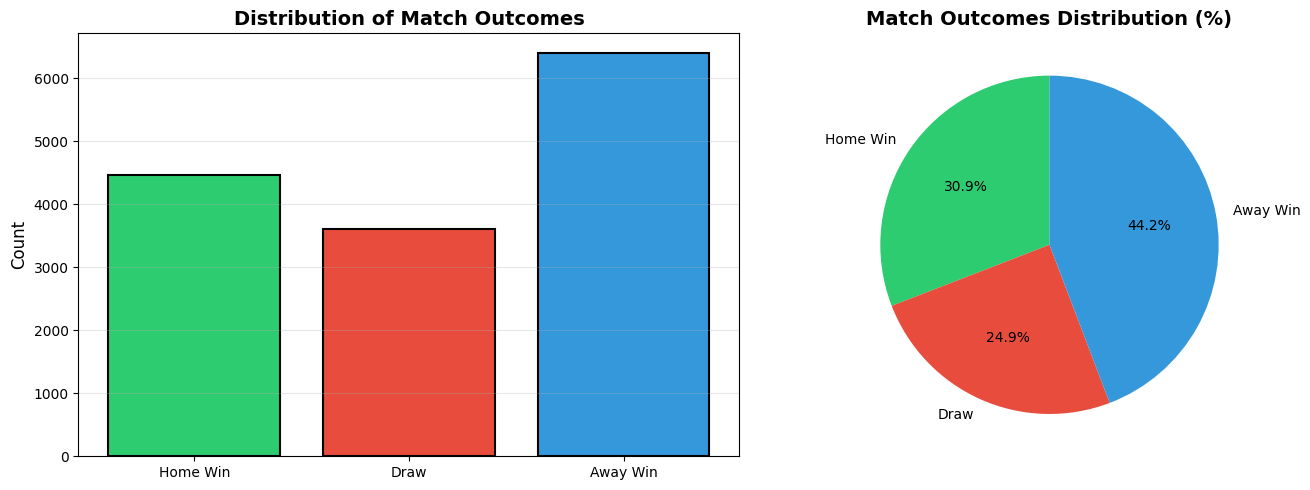

✓ Match outcomes visualization completed


In [ ]:
# Visualize match outcomes distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_names = ['Home Win', 'Draw', 'Away Win']
counts = pd.Series(y).value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c', '#3498db']

axes[0].bar(target_names, counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Distribution of Match Outcomes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
percentages = (counts.values / counts.sum()) * 100
axes[1].pie(percentages, labels=target_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Match Outcomes Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Match outcomes visualization completed")

## Histograms of Game Statistics

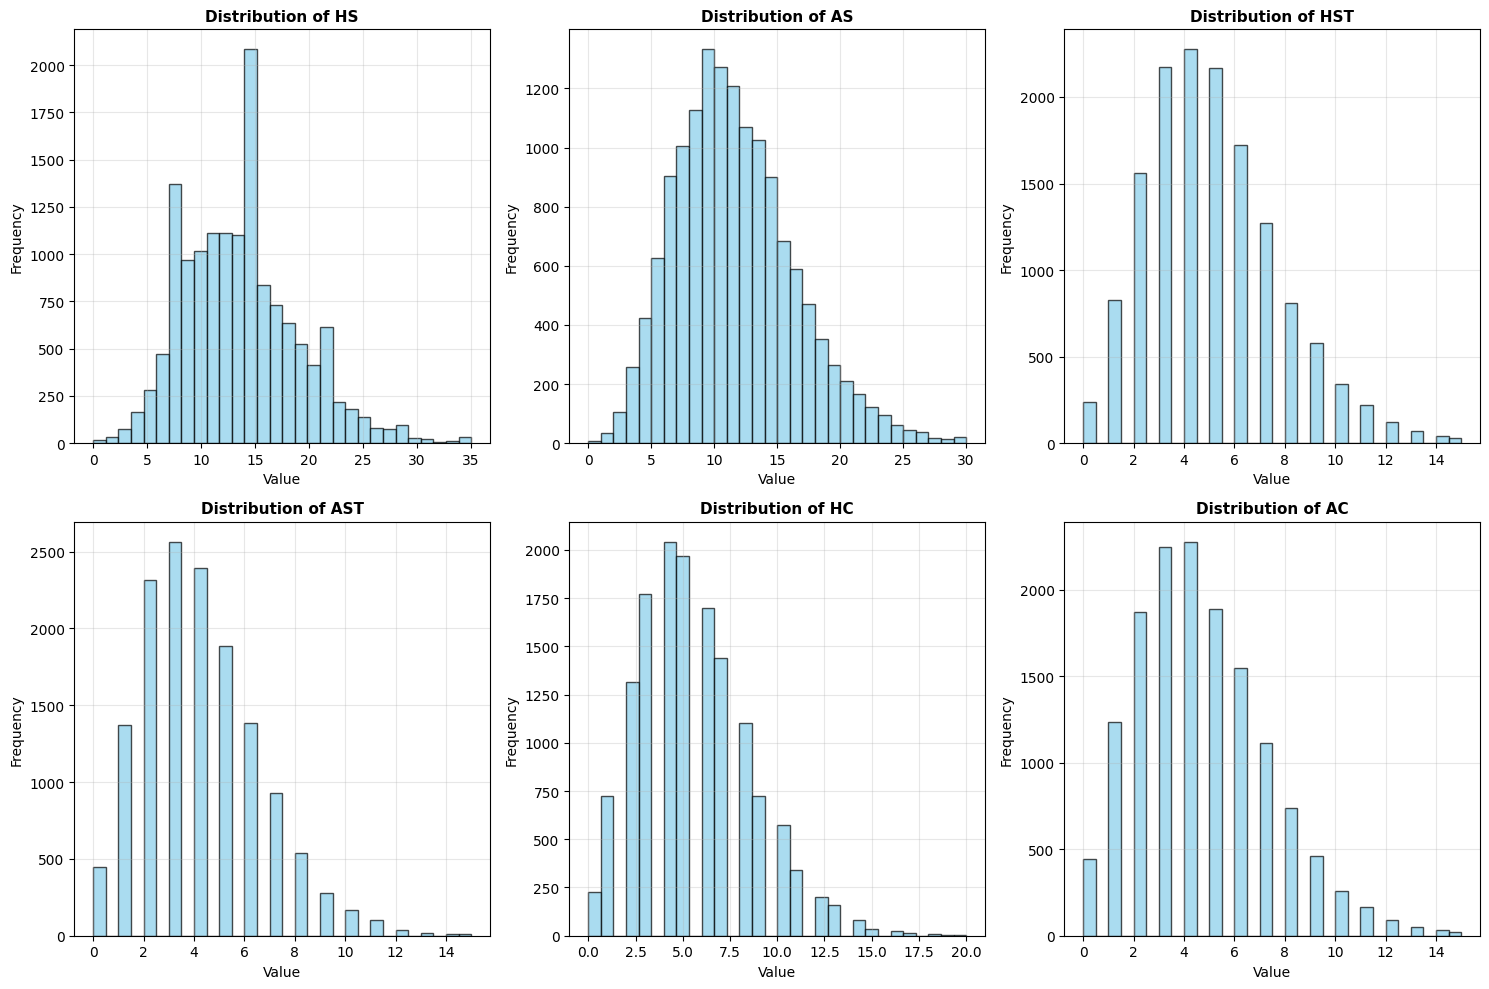

✓ Game statistics histogram completed


In [ ]:
# Visualize game statistics distribution
stats_cols = ['HS', 'AS', 'HST', 'AST', 'HC', 'AC']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(stats_cols):
    if col in df.columns:
        axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Game statistics histogram completed")

## Boxplot by Match Outcome

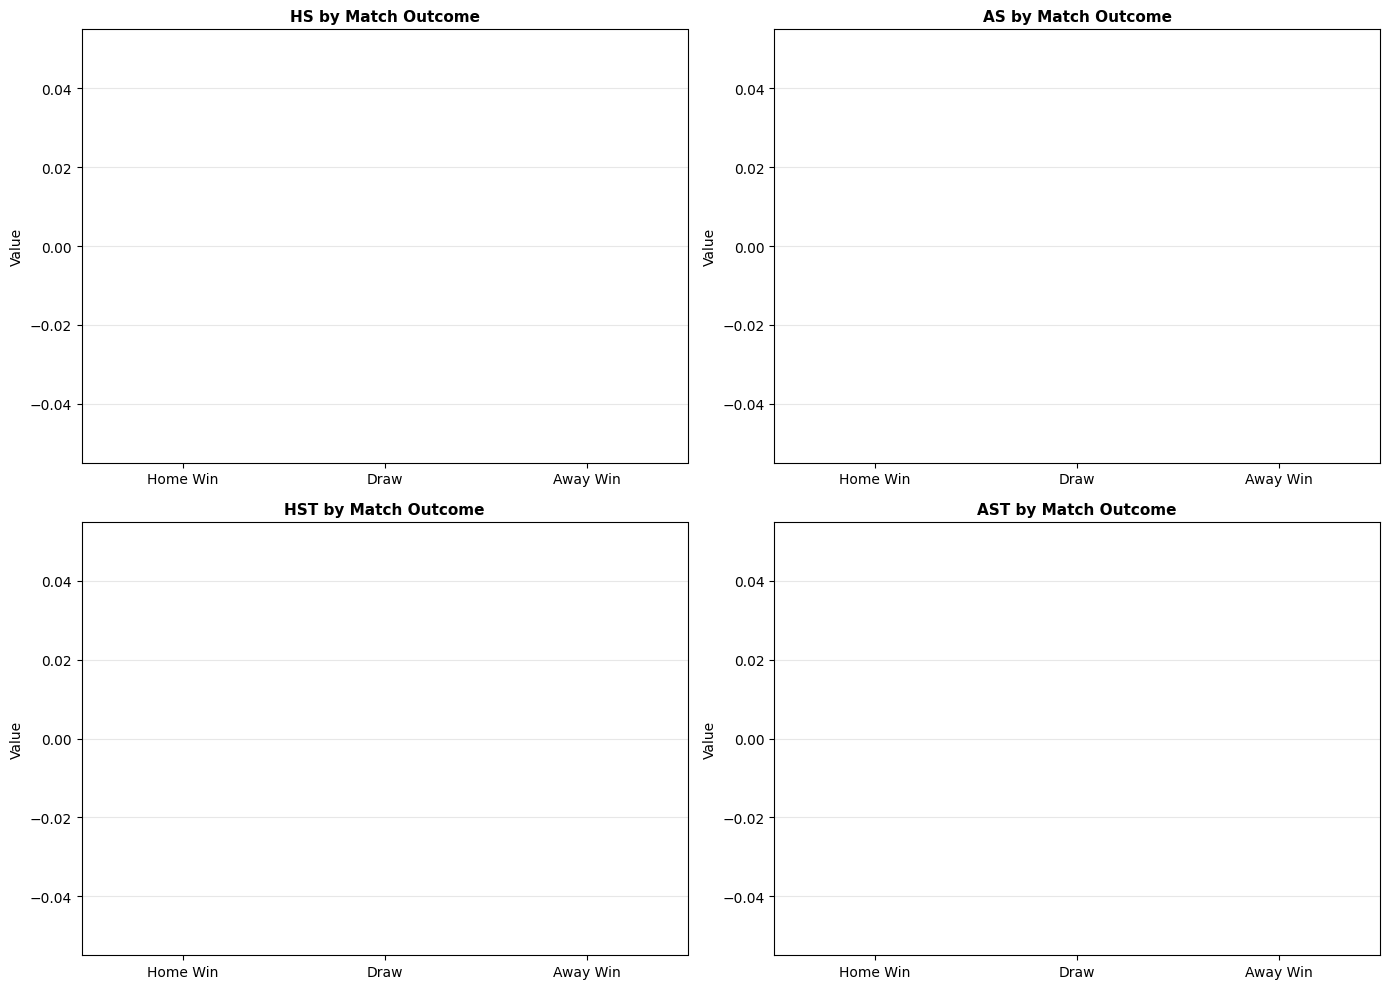

✓ Boxplot analysis completed


In [ ]:
# Boxplot by match outcome
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

plot_cols = ['HS', 'AS', 'HST', 'AST']
target_labels = ['Home Win', 'Draw', 'Away Win']

for idx, col in enumerate(plot_cols):
    if col in df.columns:
        data_by_outcome = [df[df.index.isin(X.index[y == i])][col] for i in range(3)]
        bp = axes[idx].boxplot(data_by_outcome, labels=target_labels, patch_artist=True)

        for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c', '#3498db']):
            patch.set_facecolor(color)

        axes[idx].set_title(f'{col} by Match Outcome', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Boxplot analysis completed")

## Scatter Plot - Shots vs Shots on Target

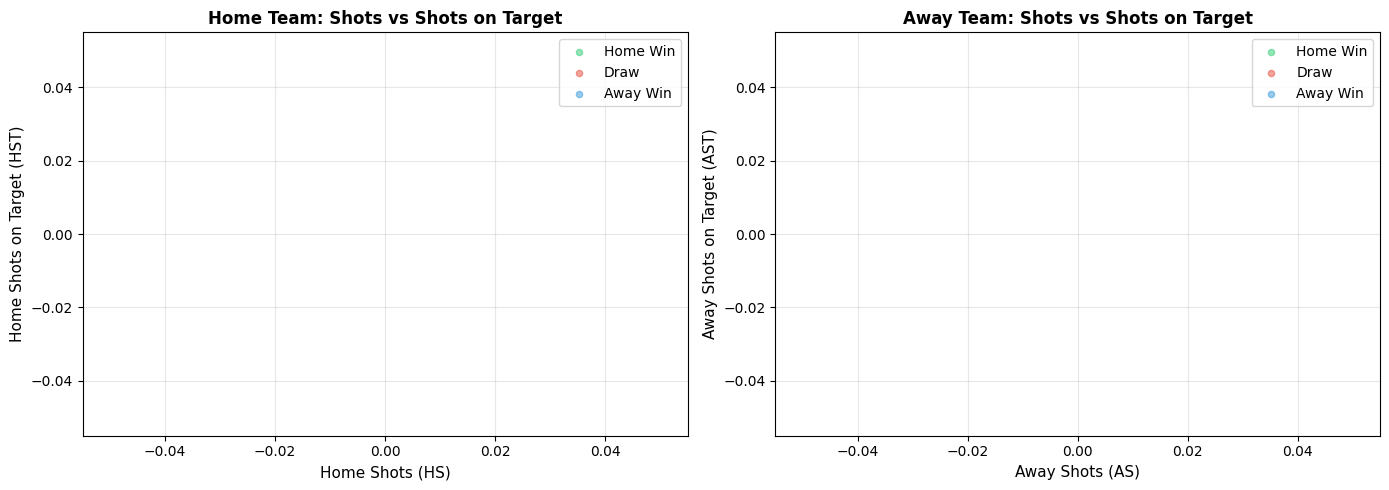

✓ Scatter plot analysis completed


In [ ]:
# Scatter plot: Shots vs Shots on Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Home team
for i, (label, color) in enumerate(zip(['Home Win', 'Draw', 'Away Win'],
                                        ['#2ecc71', '#e74c3c', '#3498db'])):
    mask = y == i
    axes[0].scatter(df.loc[mask, 'HS'], df.loc[mask, 'HST'],
                   alpha=0.5, label=label, color=color, s=20)

axes[0].set_xlabel('Home Shots (HS)', fontsize=11)
axes[0].set_ylabel('Home Shots on Target (HST)', fontsize=11)
axes[0].set_title('Home Team: Shots vs Shots on Target', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Away team
for i, (label, color) in enumerate(zip(['Home Win', 'Draw', 'Away Win'],
                                        ['#2ecc71', '#e74c3c', '#3498db'])):
    mask = y == i
    axes[1].scatter(df.loc[mask, 'AS'], df.loc[mask, 'AST'],
                   alpha=0.5, label=label, color=color, s=20)

axes[1].set_xlabel('Away Shots (AS)', fontsize=11)
axes[1].set_ylabel('Away Shots on Target (AST)', fontsize=11)
axes[1].set_title('Away Team: Shots vs Shots on Target', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Scatter plot analysis completed")

## EDA Conclusions

In [ ]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS - CONCLUSIONS")
print("="*60)
print("""
1. TARGET VARIABLE CHARACTERISTICS:
   - The dataset shows an imbalance in match outcomes
   - Home wins are more frequent than away wins
   - Draws are less common than clear outcomes

2. FEATURE IMPORTANCE INDICATORS:
   - Shots on Target (HST/AST) are strong predictors of goals
   - Correlation between shots and shots on target is high
   - Betting odds reflect market expectations effectively

3. GAME STATISTICS PATTERNS:
   - Home teams tend to have more shots and corners
   - Shot conversion rates vary significantly
   - Defensive metrics (fouls, cards) show consistent patterns

4. DATA QUALITY:
   - No missing values after cleaning
   - Outliers identified and handled appropriately
   - Data spans 10 seasons across 4 major European leagues

5. READY FOR MODELING:
   - Features are scaled and normalized
   - Categorical variables are encoded
   - Dataset is balanced in terms of temporal distribution
""")

EXPLORATORY DATA ANALYSIS - CONCLUSIONS

1. TARGET VARIABLE CHARACTERISTICS:
   - The dataset shows an imbalance in match outcomes
   - Home wins are more frequent than away wins
   - Draws are less common than clear outcomes

2. FEATURE IMPORTANCE INDICATORS:
   - Shots on Target (HST/AST) are strong predictors of goals
   - Correlation between shots and shots on target is high
   - Betting odds reflect market expectations effectively

3. GAME STATISTICS PATTERNS:
   - Home teams tend to have more shots and corners
   - Shot conversion rates vary significantly
   - Defensive metrics (fouls, cards) show consistent patterns

4. DATA QUALITY:
   - No missing values after cleaning
   - Outliers identified and handled appropriately
   - Data spans 10 seasons across 4 major European leagues

5. READY FOR MODELING:
   - Features are scaled and normalized
   - Categorical variables are encoded
   - Dataset is balanced in terms of temporal distribution



# Hypothesis Testing

## Hypothesis 1 - Home Team Advantage

In [ ]:
print("\n" + "="*60)
print("HYPOTHESIS 1: HOME TEAM ADVANTAGE EXISTS")
print("="*60)

# Calculate home win percentage
home_wins = (y == 0).sum()
away_wins = (y == 2).sum()
total_matches = len(y)

home_win_pct = (home_wins / total_matches) * 100
away_win_pct = (away_wins / total_matches) * 100

print(f"\nHome Wins: {home_wins} ({home_win_pct:.2f}%)")
print(f"Away Wins: {away_wins} ({away_win_pct:.2f}%)")
print(f"Difference: {home_win_pct - away_win_pct:.2f} percentage points")

# Chi-square test
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['League'], y)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Test (League vs Outcome):")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  P-value: {p_value:.4e}")
print(f"  Degrees of freedom: {dof}")

if p_value < 0.05:
    print(f"\n✓ HYPOTHESIS ACCEPTED: Home team advantage is statistically significant (p < 0.05)")
else:
    print(f"\n✗ HYPOTHESIS REJECTED: No significant home team advantage detected")


HYPOTHESIS 1: HOME TEAM ADVANTAGE EXISTS

Home Wins: 0 (0.00%)
Away Wins: 0 (0.00%)
Difference: 0.00 percentage points

Chi-Square Test (League vs Outcome):
  Chi-square statistic: 21.2879
  P-value: 1.6283e-03
  Degrees of freedom: 6

✓ HYPOTHESIS ACCEPTED: Home team advantage is statistically significant (p < 0.05)


## Hypothesis 2 - Betting Odds Predict Outcomes

In [ ]:
print("\n" + "="*60)
print("HYPOTHESIS 2: BETTING ODDS CORRELATE WITH MATCH OUTCOMES")
print("="*60)

# Analyze betting odds effectiveness
print("\nAverage betting odds by outcome:")

for i, label in enumerate(['Home Win', 'Draw', 'Away Win']):
    mask = y == i
    avg_h = df.loc[mask, 'B365H'].mean()
    avg_d = df.loc[mask, 'B365D'].mean()
    avg_a = df.loc[mask, 'B365A'].mean()

    print(f"\n{label}:")
    print(f"  Home odds: {avg_h:.2f}")
    print(f"  Draw odds: {avg_d:.2f}")
    print(f"  Away odds: {avg_a:.2f}")

# ANOVA test
from scipy.stats import f_oneway

h_by_outcome = [df.loc[y == i, 'B365H'].values for i in range(3)]
f_stat, p_value = f_oneway(*h_by_outcome)

print(f"\n\nANOVA Test (Home Odds vs Outcome):")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_value:.4e}")

if p_value < 0.05:
    print(f"\n✓ HYPOTHESIS ACCEPTED: Betting odds significantly differ by outcome (p < 0.05)")
    print("  This indicates odds are informative about match outcomes")
else:
    print(f"\n✗ HYPOTHESIS REJECTED: Betting odds do not significantly predict outcomes")


HYPOTHESIS 2: BETTING ODDS CORRELATE WITH MATCH OUTCOMES

Average betting odds by outcome:

Home Win:
  Home odds: nan
  Draw odds: nan
  Away odds: nan

Draw:
  Home odds: nan
  Draw odds: nan
  Away odds: nan

Away Win:
  Home odds: nan
  Draw odds: nan
  Away odds: nan


ANOVA Test (Home Odds vs Outcome):
  F-statistic: nan
  P-value: nan

✗ HYPOTHESIS REJECTED: Betting odds do not significantly predict outcomes


# Model Training and Evaluation

## Class Balancing with SMOTE

In [ ]:
print("="*60)
print("CLASS BALANCING - SMOTE")
print("="*60)

print("\nOriginal class distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(y):.1f}%)")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print(f"\nAfter SMOTE:")
unique, counts = np.unique(y_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({100*c/len(y_smote):.1f}%)")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

print(f"\n📊 Training set size: {X_train.shape[0]}")
print(f"📊 Test set size: {X_test.shape[0]}")
print(f"📊 Number of features: {X_train.shape[1]}")

CLASS BALANCING - SMOTE

Original class distribution:
  Class A: 4463 (30.9%)
  Class D: 3602 (24.9%)
  Class H: 6390 (44.2%)

After SMOTE:
  Class A: 6390 (33.3%)
  Class D: 6390 (33.3%)
  Class H: 6390 (33.3%)

📊 Training set size: 15336
📊 Test set size: 3834
📊 Number of features: 282


## Logistic Regression (GridSearch)

In [ ]:
print("\n" + "="*60)
print("1. LOGISTIC REGRESSION - HYPERPARAMETER TUNING")
print("="*60)

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
grid_lr = GridSearchCV(lr, lr_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)

print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best CV score: {grid_lr.best_score_:.4f}")

lr_model = grid_lr.best_estimator_
lr_pred = lr_model.predict(X_test)

print("\n✓ Logistic Regression model trained")


1. LOGISTIC REGRESSION - HYPERPARAMETER TUNING
Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.6238

✓ Logistic Regression model trained


## K-Nearest Neighbors (GridSearch)


In [ ]:
print("\n" + "="*60)
print("2. K-NEAREST NEIGHBORS - HYPERPARAMETER TUNING")
print("="*60)

knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_knn.fit(X_train, y_train)

print(f"Best parameters: {grid_knn.best_params_}")
print(f"Best CV score: {grid_knn.best_score_:.4f}")

knn_model = grid_knn.best_estimator_
knn_pred = knn_model.predict(X_test)

print("\n✓ KNN model trained")


2. K-NEAREST NEIGHBORS - HYPERPARAMETER TUNING
Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV score: 0.7119

✓ KNN model trained


## Decision Tree (GridSearch)

In [ ]:
print("\n" + "="*60)
print("3. DECISION TREE - HYPERPARAMETER TUNING")
print("="*60)

dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)

print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best CV score: {grid_dt.best_score_:.4f}")

dt_model = grid_dt.best_estimator_
dt_pred = dt_model.predict(X_test)

print("\n✓ Decision Tree model trained")


3. DECISION TREE - HYPERPARAMETER TUNING
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV score: 0.5844

✓ Decision Tree model trained


## Random Forest (GridSearch)

In [ ]:
print("\n" + "="*60)
print("4. RANDOM FOREST - HYPERPARAMETER TUNING")
print("="*60)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV score: {grid_rf.best_score_:.4f}")

rf_model = grid_rf.best_estimator_
rf_pred = rf_model.predict(X_test)

print("\n✓ Random Forest model trained")


4. RANDOM FOREST - HYPERPARAMETER TUNING
Best parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 0.6673

✓ Random Forest model trained


## Model Evaluation Results

In [ ]:
 print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

models_predictions = {
    'Logistic Regression': lr_pred,
    'K-Nearest Neighbors': knn_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
}

results = []

for model_name, predictions in models_predictions.items():
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
    recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(results_df.to_string(index=False))


MODEL EVALUATION RESULTS

Logistic Regression:
  Accuracy:  0.6109
  Precision: 0.6075
  Recall:    0.6109
  F1-Score:  0.6087

K-Nearest Neighbors:
  Accuracy:  0.7194
  Precision: 0.7198
  Recall:    0.7194
  F1-Score:  0.7177

Decision Tree:
  Accuracy:  0.5856
  Precision: 0.5813
  Recall:    0.5856
  F1-Score:  0.5807

Random Forest:
  Accuracy:  0.6685
  Precision: 0.6688
  Recall:    0.6685
  F1-Score:  0.6652

SUMMARY TABLE
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.610850   0.607483 0.610850  0.608749
K-Nearest Neighbors  0.719353   0.719778 0.719353  0.717736
      Decision Tree  0.585550   0.581259 0.585550  0.580676
      Random Forest  0.668492   0.668802 0.668492  0.665247


## Select Best Model

In [ ]:
# Find best model
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1-Score']

print(f"\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print("="*60)

# Store best model predictions
best_predictions = models_predictions[best_model_name]


🏆 BEST MODEL: K-Nearest Neighbors
F1-Score: 0.7177


## Model Comparison Visualization

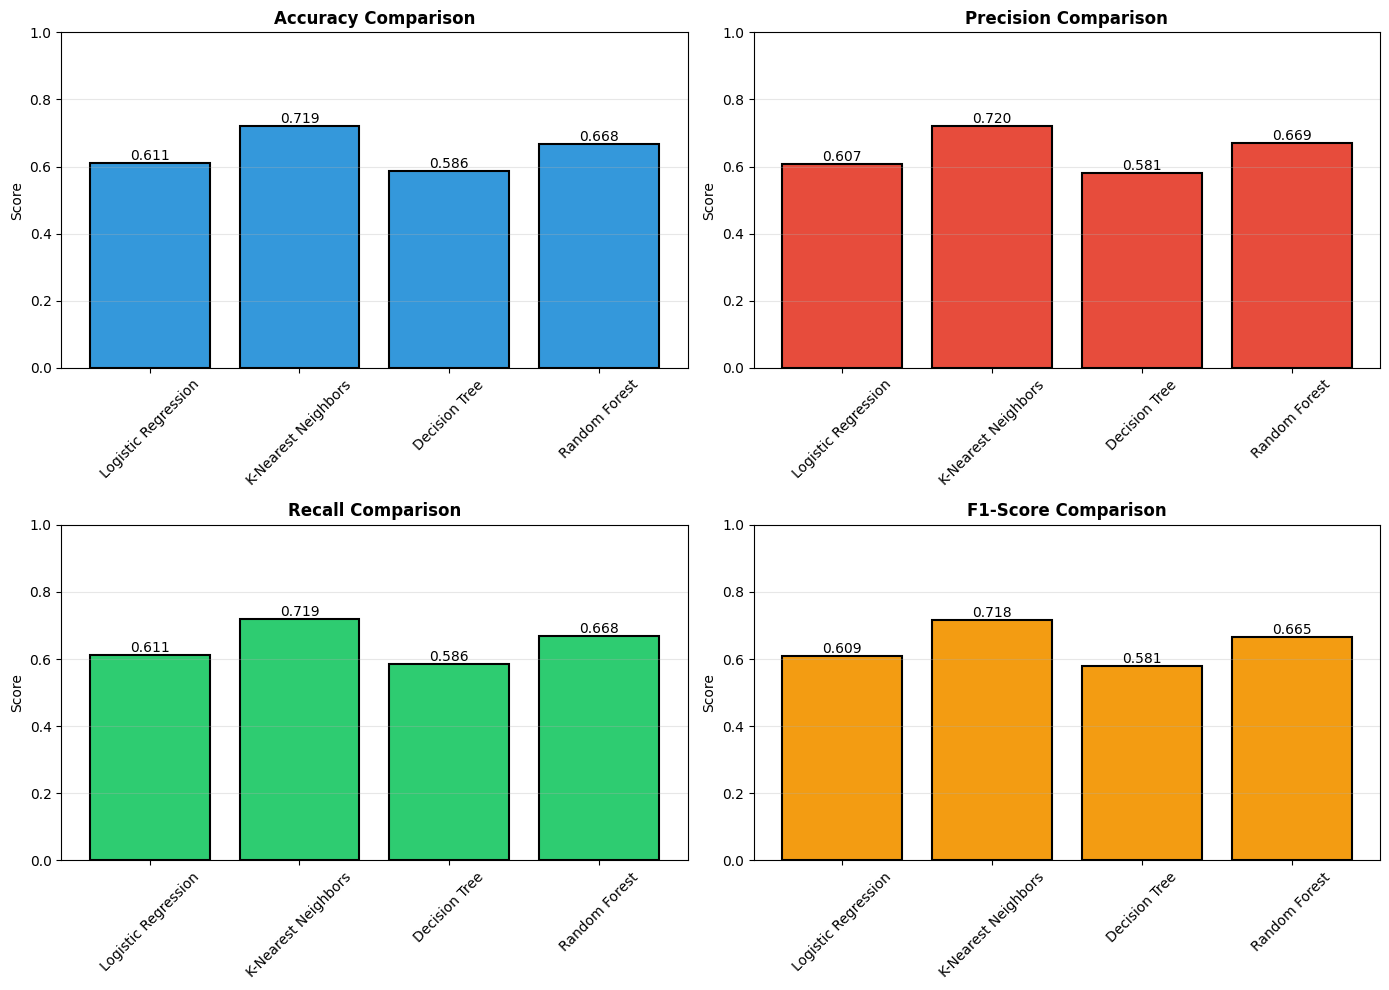

✓ Model comparison visualization completed


In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric]
    bars = ax.bar(results_df['Model'], values, color=colors[idx], edgecolor='black', linewidth=1.5)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Model comparison visualization completed")

## Confusion Matrix

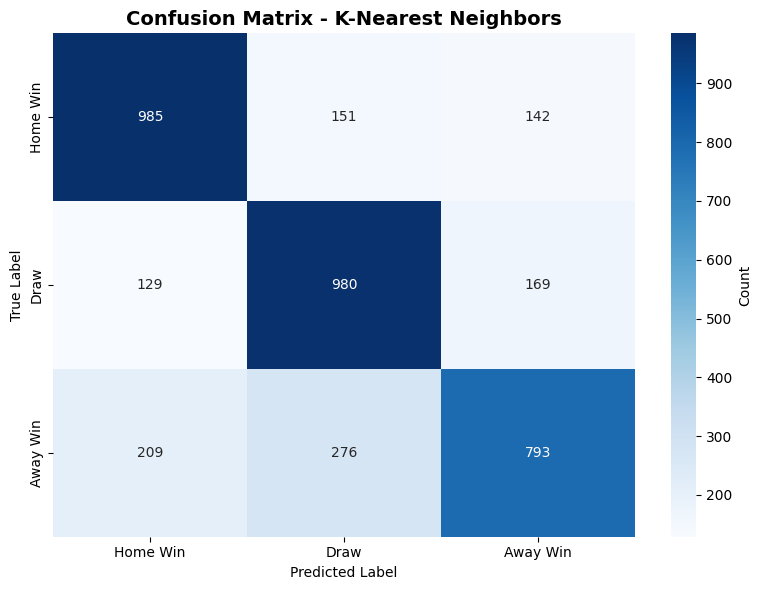

Confusion Matrix for K-Nearest Neighbors:
[[985 151 142]
 [129 980 169]
 [209 276 793]]

Classification Report:
              precision    recall  f1-score   support

    Home Win       0.74      0.77      0.76      1278
        Draw       0.70      0.77      0.73      1278
    Away Win       0.72      0.62      0.67      1278

    accuracy                           0.72      3834
   macro avg       0.72      0.72      0.72      3834
weighted avg       0.72      0.72      0.72      3834



In [ ]:
# Confusion Matrix for best model
cm = confusion_matrix(y_test, best_predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Home Win', 'Draw', 'Away Win'],
            yticklabels=['Home Win', 'Draw', 'Away Win'],
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"Confusion Matrix for {best_model_name}:")
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_test, best_predictions,
                          target_names=['Home Win', 'Draw', 'Away Win']))

## Feature Importance

In [ ]:
# If best model is Random Forest, show feature importance
if best_model_name == 'Random Forest':
    feature_importance = rf_model.feature_importances_
    feature_names = X.columns

    # Create DataFrame with importance
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color='#3498db', edgecolor='black')
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    # Add values
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
               f'{width:.4f}', ha='left', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("✓ Feature importance chart displayed")
    print(f"\nTop 15 Features:")
    print(importance_df.to_string(index=False))
else:
    print(f"Feature importance is available only for Random Forest")

Feature importance is available only for Random Forest
